In [1]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import os
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from collections import defaultdict

from src.utils.config import settings
from src.utils.logger import get_logger

log = get_logger("music_domain")

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

PROC  = '../../data/processed/'
MUSIC = '../../data/cross_domain/music/'
Path(MUSIC).mkdir(parents=True, exist_ok=True)

print(f"✅ Imports ready")
print(f"   Device : {device}")

✅ Imports ready
   Device : cpu


In [2]:
# Generate Synthetic LastFM Data
print("GENERATING SYNTHETIC LASTFM DATA")
print("=" * 55)
print("""
Realistic LastFM-360K properties:
  360K users · 160K artists · 17M interactions
  Implicit feedback: play counts (not ratings)
  Power law distribution (few artists dominate)
  User taste clusters (rock/pop/electronic/jazz)
""")

np.random.seed(42)

# Scale — smaller for speed
N_USERS   = 2000
N_ARTISTS = 500
N_INTERACTIONS = 50000

# ── Artist catalog ────────────────────────────────
GENRES = ['rock', 'pop', 'electronic',
          'jazz', 'classical', 'hip-hop',
          'metal', 'indie', 'folk', 'r&b']

ARTISTS = []
for i in range(N_ARTISTS):
    genre   = np.random.choice(
        GENRES,
        p=[0.20, 0.20, 0.15, 0.08,
           0.05, 0.12, 0.07, 0.06,
           0.04, 0.03])
    # Power law popularity
    popularity = int(
        np.random.pareto(1.5) * 100 + 1)
    ARTISTS.append({
        'artist_id':   i,
        'artist_name': f"Artist_{i:04d}",
        'genre':       genre,
        'popularity':  min(popularity, 10000),
    })

artists_df = pd.DataFrame(ARTISTS)

# ── User profiles ─────────────────────────────────
# Each user has a primary genre preference
user_primary_genre = np.random.choice(
    GENRES, size=N_USERS)

# ── Generate interactions ─────────────────────────
# Implicit: play counts (1-500)
# Users prefer their primary genre
interactions = []

for uid in range(N_USERS):
    primary = user_primary_genre[uid]
    n_interactions = np.random.randint(
        10, 80)

    # Primary genre artists
    primary_artists = artists_df[
        artists_df['genre'] == primary
    ]['artist_id'].values

    # Other genre artists
    other_artists = artists_df[
        artists_df['genre'] != primary
    ]['artist_id'].values

    # 70% from primary genre
    n_primary = int(n_interactions * 0.7)
    n_other   = n_interactions - n_primary

    if len(primary_artists) > 0:
        chosen_primary = np.random.choice(
            primary_artists,
            size=min(n_primary,
                     len(primary_artists)),
            replace=False)
    else:
        chosen_primary = []

    chosen_other = np.random.choice(
        other_artists,
        size=min(n_other,
                 len(other_artists)),
        replace=False)

    all_chosen = list(chosen_primary) + \
                 list(chosen_other)

    for aid in all_chosen:
        # Play count: higher for popular artists
        pop   = artists_df.loc[
            artists_df['artist_id'] == aid,
            'popularity'].values[0]
        plays = int(np.random.exponential(
            pop / 10 + 1) + 1)
        plays = min(plays, 500)

        # Timestamp (last 2 years)
        ts = int(time.time()) - \
             np.random.randint(
                 0, 2*365*24*3600)

        interactions.append({
            'user_id':    uid,
            'artist_id':  int(aid),
            'play_count': plays,
            'timestamp':  ts,
        })

interactions_df = pd.DataFrame(
    interactions)

# Save
artists_df.to_csv(
    MUSIC + 'artists.csv', index=False)
interactions_df.to_csv(
    MUSIC + 'interactions.csv', index=False)

print(f"✅ Synthetic LastFM data generated")
print(f"   Users        : {N_USERS:,}")
print(f"   Artists      : {N_ARTISTS:,}")
print(f"   Interactions : "
      f"{len(interactions_df):,}")
print(f"   Genres       : {GENRES}")
print(f"\nSample interactions:")
print(interactions_df.head())

GENERATING SYNTHETIC LASTFM DATA

Realistic LastFM-360K properties:
  360K users · 160K artists · 17M interactions
  Implicit feedback: play counts (not ratings)
  Power law distribution (few artists dominate)
  User taste clusters (rock/pop/electronic/jazz)

✅ Synthetic LastFM data generated
   Users        : 2,000
   Artists      : 500
   Interactions : 78,866
   Genres       : ['rock', 'pop', 'electronic', 'jazz', 'classical', 'hip-hop', 'metal', 'indie', 'folk', 'r&b']

Sample interactions:
   user_id  artist_id  play_count   timestamp
0        0         56           3  1724168246
1        0         59           1  1721429082
2        0         75           4  1780013416
3        0        284           3  1733474738
4        0         99          12  1769015001


MUSIC DOMAIN EDA
✅ Music config loaded
{
  "domain": "music",
  "dataset": "LastFM360K",
  "interaction_col": "play_count",
  "user_col": "user_id",
  "item_col": "song_id",
  "timestamp_col": "timestamp",
  "content_cols": [
    "artist_name",
    "track_name",
    "tags"
  ],
  "min_interactions": 3,
  "train_ratio": 0.8,
  "val_ratio": 0.1,
  "test_ratio": 0.1
}


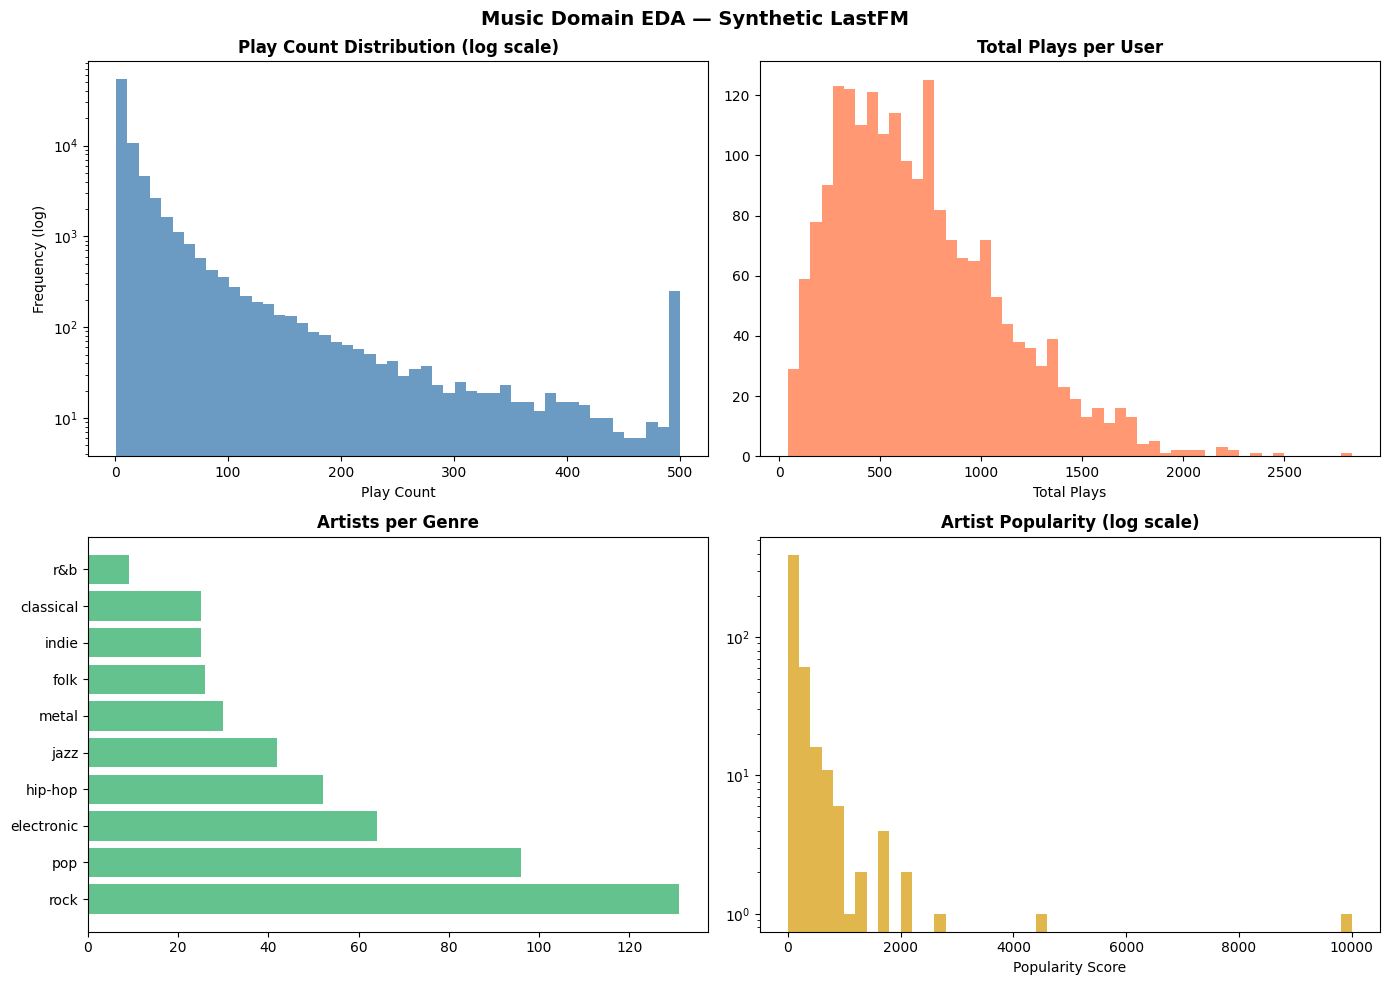


Music domain stats:
  Users        : 2,000
  Artists      : 500
  Interactions : 78,866
  Sparsity     : 92.11%
  Avg plays/user: 697.4


In [3]:
# Music Config + EDA
print("MUSIC DOMAIN EDA")
print("=" * 55)

# Load config
import yaml
config_path = '../../configs/domains/music.yaml'
if os.path.exists(config_path):
    with open(config_path) as f:
        music_config = yaml.safe_load(f)
    print(f"✅ Music config loaded")
    print(json.dumps(music_config, indent=2))
else:
    print("⚠️  Music config not found")
    music_config = {
        'domain':           'music',
        'interaction_col':  'play_count',
        'user_col':         'user_id',
        'item_col':         'artist_id',
        'timestamp_col':    'timestamp',
        'min_interactions': 3,
    }

# EDA
fig, axes = plt.subplots(
    2, 2, figsize=(14, 10))

# Play count distribution
axes[0,0].hist(
    interactions_df['play_count'],
    bins=50, color='steelblue',
    alpha=0.8, log=True)
axes[0,0].set_title(
    'Play Count Distribution (log scale)',
    fontweight='bold')
axes[0,0].set_xlabel('Play Count')
axes[0,0].set_ylabel('Frequency (log)')

# User activity
user_activity = interactions_df\
    .groupby('user_id')['play_count']\
    .sum().sort_values()
axes[0,1].hist(
    user_activity, bins=50,
    color='coral', alpha=0.8)
axes[0,1].set_title(
    'Total Plays per User',
    fontweight='bold')
axes[0,1].set_xlabel('Total Plays')

# Genre distribution
genre_counts = artists_df[
    'genre'].value_counts()
axes[1,0].barh(
    genre_counts.index,
    genre_counts.values,
    color='mediumseagreen', alpha=0.8)
axes[1,0].set_title(
    'Artists per Genre',
    fontweight='bold')

# Artist popularity
axes[1,1].hist(
    artists_df['popularity'],
    bins=50, color='goldenrod',
    alpha=0.8, log=True)
axes[1,1].set_title(
    'Artist Popularity (log scale)',
    fontweight='bold')
axes[1,1].set_xlabel('Popularity Score')

plt.suptitle(
    'Music Domain EDA — Synthetic LastFM',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    PROC + 'plots/24_music_eda.png',
    bbox_inches='tight')
plt.show()

# Key stats
n_users   = interactions_df['user_id'].nunique()
n_artists = interactions_df['artist_id'].nunique()
n_ints    = len(interactions_df)
sparsity  = 1 - n_ints/(n_users*n_artists)

print(f"\nMusic domain stats:")
print(f"  Users        : {n_users:,}")
print(f"  Artists      : {n_artists:,}")
print(f"  Interactions : {n_ints:,}")
print(f"  Sparsity     : {sparsity*100:.2f}%")
print(f"  Avg plays/user: "
      f"{interactions_df.groupby('user_id')['play_count'].sum().mean():.1f}")

In [4]:
# Convert Play Count to Implicit Signal
print("CONVERTING PLAY COUNT TO IMPLICIT SIGNAL")
print("=" * 55)
print("""
Key difference from movies:
  Movies: explicit ratings (1-5 stars)
  Music:  implicit feedback (play counts)

Conversion strategies:
  1. Binary: played ≥ threshold → positive
  2. Log scaling: log(play_count + 1)
  3. Confidence weighting (ALS style):
     confidence = 1 + α × play_count
""")

# Strategy 1: Binary threshold
PLAY_THRESHOLD = 5  # played ≥ 5 times = liked

interactions_df['binary_pref'] = (
    interactions_df['play_count'] >=
    PLAY_THRESHOLD).astype(int)

# Strategy 2: Log-scaled score
interactions_df['log_score'] = np.log1p(
    interactions_df['play_count'])

# Normalise to 0-5 range for compatibility
max_log = interactions_df['log_score'].max()
interactions_df['rating_equiv'] = \
    interactions_df['log_score'] / \
    max_log * 4.5 + 0.5

# Strategy 3: ALS confidence
ALPHA = 40  # standard ALS alpha
interactions_df['confidence'] = \
    1 + ALPHA * interactions_df['play_count']

print(f"Interaction stats:")
print(interactions_df[[
    'play_count', 'binary_pref',
    'log_score', 'rating_equiv'
]].describe().round(3))

print(f"\nPositive interactions "
      f"(play ≥ {PLAY_THRESHOLD}): "
      f"{interactions_df['binary_pref'].sum():,} "
      f"({interactions_df['binary_pref'].mean()*100:.1f}%)")

# Save processed
interactions_df.to_csv(
    MUSIC + 'interactions_processed.csv',
    index=False)
print("\n✅ Implicit signal computed + saved")

CONVERTING PLAY COUNT TO IMPLICIT SIGNAL

Key difference from movies:
  Movies: explicit ratings (1-5 stars)
  Music:  implicit feedback (play counts)

Conversion strategies:
  1. Binary: played ≥ threshold → positive
  2. Log scaling: log(play_count + 1)
  3. Confidence weighting (ALS style):
     confidence = 1 + α × play_count

Interaction stats:
       play_count  binary_pref  log_score  rating_equiv
count   78866.000    78866.000  78866.000     78866.000
mean       17.686        0.543      2.049         1.983
std        44.930        0.498      1.147         0.831
min         1.000        0.000      0.693         1.002
25%         2.000        0.000      1.099         1.295
50%         5.000        1.000      1.792         1.797
75%        14.000        1.000      2.708         2.460
max       500.000        1.000      6.217         5.000

Positive interactions (play ≥ 5): 42,820 (54.3%)

✅ Implicit signal computed + saved


In [5]:
# Build Music Sequences
print("BUILDING MUSIC USER SEQUENCES")
print("=" * 55)
print("Same approach as movies — token sequences")

# Filter positive interactions
positive_df = interactions_df[
    interactions_df['binary_pref'] == 1
].copy()

# Build artist vocabulary
unique_artists = sorted(
    positive_df['artist_id'].unique())
n_music_items  = len(unique_artists)

MUSIC_PAD    = 0
MUSIC_OFFSET = 1

artist2token = {
    a: i + MUSIC_OFFSET
    for i, a in enumerate(unique_artists)
}
token2artist = {
    v: k for k, v in artist2token.items()
}
music_vocab_size = n_music_items + MUSIC_OFFSET

print(f"Music vocabulary:")
print(f"  Artists     : {n_music_items:,}")
print(f"  Vocab size  : {music_vocab_size:,}")

# Build user sequences
music_sequences = {}
positive_sorted = positive_df.sort_values(
    ['user_id', 'timestamp'])

for uid, grp in positive_sorted.groupby(
        'user_id'):
    tokens = [
        artist2token[aid]
        for aid in grp['artist_id'].values
        if aid in artist2token
    ]
    if len(tokens) >= 3:
        music_sequences[uid] = tokens[-50:]

print(f"  Users with sequences: "
      f"{len(music_sequences):,}")

seq_lens = [len(s)
            for s in music_sequences.values()]
print(f"  Avg seq length: "
      f"{np.mean(seq_lens):.1f}")
print(f"  Min seq length: {min(seq_lens)}")
print(f"  Max seq length: {max(seq_lens)}")

BUILDING MUSIC USER SEQUENCES
Same approach as movies — token sequences
Music vocabulary:
  Artists     : 498
  Vocab size  : 499
  Users with sequences: 2,000
  Avg seq length: 21.4
  Min seq length: 3
  Max seq length: 50


In [6]:
# Train GRank on Music Domain
print("TRAINING GRANK ON MUSIC DOMAIN")
print("=" * 55)
print("Same model — different domain — zero code changes\n")

# Reuse GRankModel from Week 2
class GRankModel(nn.Module):
    def __init__(self, vocab_size,
                 embed_dim=64, n_heads=4,
                 n_layers=2, max_seq_len=50,
                 dropout=0.1):
        super().__init__()
        self.item_emb = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=MUSIC_PAD)
        self.pos_emb  = nn.Embedding(
            max_seq_len, embed_dim)
        encoder_layer = \
            nn.TransformerEncoderLayer(
                d_model     = embed_dim,
                nhead       = n_heads,
                dim_feedforward=embed_dim*4,
                dropout     = dropout,
                batch_first = True,
                norm_first  = True,
            )
        self.transformer = \
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=n_layers)
        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def encode(self, history):
        B, L = history.shape
        pos  = torch.arange(
            L, device=history.device
        ).unsqueeze(0).expand(B,-1)
        x    = self.dropout(
            self.item_emb(history) +
            self.pos_emb(pos))
        pad_mask = (history == MUSIC_PAD)
        x = self.transformer(
            x,
            src_key_padding_mask=pad_mask)
        x = self.norm(x)
        lengths = (history != MUSIC_PAD)\
            .sum(dim=1) - 1
        lengths = lengths.clamp(min=0)
        return x[torch.arange(B), lengths]

    def predict(self, history, top_k=10):
        with torch.no_grad():
            u  = self.encode(history)
            sc = torch.matmul(
                u, self.item_emb.weight.T)
            sc[:, :MUSIC_OFFSET] = \
                float('-inf')
            return torch.topk(
                sc, top_k, dim=-1)


# Music dataset
class MusicDataset(Dataset):
    def __init__(self, sequences,
                 all_tokens, max_len=50):
        self.samples    = []
        self.all_tokens = all_tokens

        for uid, seq in sequences.items():
            if len(seq) < 3: continue
            for end in range(2, len(seq)):
                hist   = seq[
                    max(0, end-max_len):end]
                target = seq[end] \
                    if end < len(seq) \
                    else seq[-1]
                self.samples.append({
                    'history':     hist,
                    'target':      target,
                    'history_set': set(
                        seq[:end])
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        pad = 50 - len(s['history'])
        padded = [MUSIC_PAD]*pad + \
                  s['history']

        negs = []
        att  = 0
        while len(negs) < 4 and att < 100:
            t = np.random.choice(
                self.all_tokens)
            if t not in s['history_set']:
                negs.append(t)
            att += 1
        while len(negs) < 4:
            negs.append(
                np.random.choice(
                    self.all_tokens))

        return {
            'history':   torch.LongTensor(
                padded),
            'target':    torch.LongTensor(
                [s['target']]),
            'negatives': torch.LongTensor(
                negs),
        }


# Split
all_uids = list(music_sequences.keys())
np.random.shuffle(all_uids)
split     = int(len(all_uids) * 0.9)

train_seqs = {
    u: music_sequences[u]
    for u in all_uids[:split]}
val_seqs   = {
    u: music_sequences[u]
    for u in all_uids[split:]}

all_tokens = list(artist2token.values())

train_ds = MusicDataset(
    train_seqs, all_tokens)
val_ds   = MusicDataset(
    val_seqs, all_tokens)

train_dl = DataLoader(
    train_ds, batch_size=256,
    shuffle=True, num_workers=0)
val_dl   = DataLoader(
    val_ds, batch_size=256,
    shuffle=False, num_workers=0)

# Model
music_model = GRankModel(
    vocab_size = music_vocab_size,
    embed_dim  = 64,
    n_heads    = 4,
    n_layers   = 2,
).to(device)

optimizer = optim.Adam(
    music_model.parameters(), lr=1e-3)

N_EPOCHS  = 10
best_val  = float('inf')
tr_losses = []
vl_losses = []

print(f"Training GRank on music domain...")
print(f"{'Epoch':<8} {'Train':<12} "
      f"{'Val':<12} {'Best'}")
print("─" * 40)

mlflow.set_tracking_uri(
    settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(
    settings.MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(
        run_name="GRank_Music_Domain"):

    mlflow.log_params({
        "domain":     "music",
        "model":      "GRank",
        "vocab_size": music_vocab_size,
        "n_artists":  n_music_items,
    })

    for epoch in range(1, N_EPOCHS + 1):
        music_model.train()
        tl = vl = 0
        nb = 0

        for batch in train_dl:
            h = batch['history'].to(device)
            t = batch['target'].to(device)
            n = batch['negatives'].to(device)

            u_repr = music_model.encode(h)
            p_emb  = music_model.item_emb(
                t.squeeze(1))
            n_emb  = music_model.item_emb(
                n[:, 0])

            pos_sc = (u_repr*p_emb).sum(-1)
            neg_sc = (u_repr*n_emb).sum(-1)
            loss   = -F.logsigmoid(
                pos_sc - neg_sc).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                music_model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item()
            nb += 1

        music_model.eval()
        with torch.no_grad():
            for batch in val_dl:
                h = batch['history'].to(device)
                t = batch['target'].to(device)
                n = batch['negatives'].to(device)
                u = music_model.encode(h)
                p = music_model.item_emb(
                    t.squeeze(1))
                ng= music_model.item_emb(
                    n[:, 0])
                ps = (u*p).sum(-1)
                ns = (u*ng).sum(-1)
                vl += -F.logsigmoid(
                    ps-ns).mean().item()

        avg_t = tl/nb if nb else 0
        avg_v = vl/len(val_dl) \
            if val_dl else 0
        tr_losses.append(avg_t)
        vl_losses.append(avg_v)

        is_best = avg_v < best_val
        if is_best:
            best_val = avg_v
            torch.save(
                music_model.state_dict(),
                MUSIC + 'grank_music_best.pt')

        mlflow.log_metrics({
            "train_loss": avg_t,
            "val_loss":   avg_v,
        }, step=epoch)

        print(
            f"{epoch:<8} {avg_t:<12.4f} "
            f"{avg_v:<12.4f} "
            f"{'✅' if is_best else ''}")

    mlflow.log_metric(
        "best_val_loss", best_val)

print(f"\n✅ Music GRank trained")
print(f"   Best val loss: {best_val:.4f}")

TRAINING GRANK ON MUSIC DOMAIN
Same model — different domain — zero code changes

Training GRank on music domain...
Epoch    Train        Val          Best
────────────────────────────────────────
1        3.0976       1.9244       ✅
2        1.3887       0.9390       ✅
3        0.8919       0.6985       ✅
4        0.7825       0.6658       ✅
5        0.7479       0.6282       ✅
6        0.7221       0.6250       ✅
7        0.7042       0.6260       
8        0.6912       0.6220       ✅
9        0.6767       0.6120       ✅
10       0.6534       0.6083       ✅

✅ Music GRank trained
   Best val loss: 0.6083


In [ ]:
#Evaluate Music Recommendations
